# Movie Box-Office Success Predictor — Model Training & Evaluation

**Author:** Bennett Speicher
**Course:** DATA 606 Capstone (Summer 2026), UMBC — Dr. Chaojie (Jay) Wang

This notebook builds on the EDA (`eda.ipynb`). It trains and compares classification models that predict whether
a film is a **financial success** (`revenue >= 2 x budget`) using **only pre-release information** — nothing that
would be unknown before a movie opens.

**Feature engineering beyond the EDA:** in addition to the EDA features (budget, runtime, genre, language,
timing), this notebook adds four engineered pre-release signals that improved performance:
- `is_sequel` — franchise/sequel/adaptation signal (from plot keywords and title patterns)
- `is_major_studio` — whether a major studio (Disney, Warner Bros., Universal, etc.) produced the film
- `year` — release year (films' success rates shift across eras)
- `budget_per_min_log` — production spend intensity (budget per minute of runtime)

**Models compared:** Logistic Regression, Random Forest (tuned), Gradient Boosting.
**Evaluation:** a held-out 80/20 test set *and* 5-fold cross-validation (for robustness), with ROC curves,
a confusion matrix, and feature importances.


In [1]:
import pandas as pd
import numpy as np
import json
import re

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "png"

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 40)
pd.options.display.float_format = lambda x: f"{x:,.3f}"


## 1. Load data and build the modeling table
Same cleaning as the EDA (released films, plausible budget ≥ $1,000, revenue > 0, valid release date),
plus the additional engineered features described above.

In [2]:
def parse_names(s):
    """Extract 'name' values from a TMDB JSON-encoded cell."""
    try:
        return [d["name"] for d in json.loads(s)]
    except Exception:
        return []

df = pd.read_csv("../data/tmdb_5000_movies.csv")

# --- Cleaning (identical to the EDA) ---
d = df[df["status"] == "Released"].copy()
d = d[(d["budget"] >= 1000) & (d["revenue"] > 0)]   # drop unknown (0) & impossible (<$1,000) budgets
d = d.dropna(subset=["release_date"]).drop_duplicates(subset=["title", "release_date"]).copy()

# --- Parse JSON columns ---
d["genre_list"] = d["genres"].apply(parse_names)
d["keyword_list"] = d["keywords"].apply(parse_names)
d["company_list"] = d["production_companies"].apply(parse_names)
d["primary_genre"] = d["genre_list"].apply(lambda g: g[0] if g else "Unknown")
d["n_genres"] = d["genre_list"].apply(len)
d["n_production_companies"] = d["company_list"].apply(len)
d["n_spoken_languages"] = d["spoken_languages"].apply(lambda s: len(parse_names(s)))
d["is_english"] = (d["original_language"] == "en").astype(int)

# --- Timing features ---
d["release_date"] = pd.to_datetime(d["release_date"], errors="coerce")
d["year"] = d["release_date"].dt.year
d["month"] = d["release_date"].dt.month
d["budget_log"] = np.log10(d["budget"])

def to_season(m):
    if m in (12, 1, 2): return "Winter"
    if m in (3, 4, 5):  return "Spring"
    if m in (6, 7, 8):  return "Summer"
    return "Fall"

def to_window(m):
    if m in (5, 6, 7, 8): return "Summer"
    if m in (11, 12):     return "Holiday"
    if m in (1, 2):       return "Dump"
    if m in (9, 10):      return "Fall"
    return "Spring"

d["season"] = d["month"].apply(to_season)
d["release_window"] = d["month"].apply(to_window)

def has(gl, *t): return int(any(x in gl for x in t))
d["is_summer_action_adv"] = d.apply(lambda r: int(has(r["genre_list"], "Action", "Adventure") and r["month"] in (5, 6, 7)), axis=1)
d["is_october_horror"]    = d.apply(lambda r: int(has(r["genre_list"], "Horror") and r["month"] == 10), axis=1)
d["is_holiday_family"]    = d.apply(lambda r: int(has(r["genre_list"], "Family", "Animation") and r["month"] in (11, 12)), axis=1)

# --- NEW: franchise/sequel signal (keywords + title patterns like '2', 'Part', 'Chapter') ---
sequel_keywords = {"sequel", "based on novel", "based on comic", "based on comic book", "superhero",
                   "marvel comic", "dc comics", "based on young adult novel", "remake", "spin off",
                   "saga", "trilogy"}
kw_flag = d["keyword_list"].apply(lambda ks: int(any(k in sequel_keywords for k in ks)))
title_flag = d["title"].fillna("").apply(lambda t: int(bool(re.search(r"\b(2|3|4|II|III|IV|V)\b|Part |Chapter ", t))))
d["is_sequel"] = ((kw_flag == 1) | (title_flag == 1)).astype(int)

# --- NEW: major-studio flag ---
MAJORS = {"Universal Pictures", "Warner Bros.", "Paramount Pictures",
          "Twentieth Century Fox Film Corporation", "Columbia Pictures", "Walt Disney Pictures",
          "New Line Cinema", "Metro-Goldwyn-Mayer (MGM)", "DreamWorks SKG", "Lionsgate",
          "Miramax Films", "Touchstone Pictures", "Sony Pictures"}
d["is_major_studio"] = d["company_list"].apply(lambda cs: int(any(c in MAJORS for c in cs)))

# --- NEW: spend intensity ---
d["budget_per_min_log"] = np.log10(np.maximum(d["budget"] / np.maximum(d["runtime"], 1), 1))

# --- Target ---
d["success"] = (d["revenue"] >= 2 * d["budget"]).astype(int)

print("Modeling table:", d.shape[0], "movies")
print(f"Success rate  : {d['success'].mean()*100:.1f}%")
print(f"Sequel/franchise films: {int(d['is_sequel'].sum())}  (success {d.loc[d.is_sequel==1,'success'].mean()*100:.1f}% vs {d.loc[d.is_sequel==0,'success'].mean()*100:.1f}%)")
print(f"Major-studio films    : {int(d['is_major_studio'].sum())}  (success {d.loc[d.is_major_studio==1,'success'].mean()*100:.1f}% vs {d.loc[d.is_major_studio==0,'success'].mean()*100:.1f}%)")


Modeling table: 3215 movies
Success rate  : 56.1%
Sequel/franchise films: 521  (success 68.1% vs 53.7%)
Major-studio films    : 1662  (success 60.9% vs 50.9%)


## 2. Feature set (pre-release only — no leakage)
Post-release fields (`revenue`, `roi`, `profit`, `popularity`, `vote_average`, `vote_count`) are **excluded**.

In [3]:
numeric_features = ["budget_log", "runtime", "n_genres", "n_production_companies",
                    "n_spoken_languages", "year", "budget_per_min_log"]
flag_features = ["is_english", "is_summer_action_adv", "is_october_horror", "is_holiday_family",
                 "is_sequel", "is_major_studio"]
categorical_features = ["primary_genre", "season", "release_window"]

feature_cols = numeric_features + flag_features + categorical_features
X = d[feature_cols].copy()
y = d["success"].copy()
print("Total input columns (pre-encoding):", len(feature_cols))


Total input columns (pre-encoding): 16


## 3. Preprocessing and train/test split
Median imputation + standardization for numeric features, one-hot encoding for categoricals,
stratified **80/20** split.

In [4]:
preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), numeric_features),
    ("flag", "passthrough", flag_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Baseline (always predict majority class): {max(y.mean(), 1-y.mean())*100:.1f}% accuracy")


Train: 2572 rows | Test: 643 rows
Baseline (always predict majority class): 56.1% accuracy


## 4. Train and evaluate on the held-out test set
The Random Forest uses light tuning (more trees, depth cap, minimum leaf size) which improved its
cross-validated performance.

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Random Forest (tuned)": RandomForestClassifier(n_estimators=800, max_depth=12,
                                                    min_samples_leaf=5, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

results, fitted, roc_data = [], {}, {}
for name, clf in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", clf)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    results.append({"Model": name,
                    "Accuracy": accuracy_score(y_test, pred),
                    "Precision": precision_score(y_test, pred),
                    "Recall": recall_score(y_test, pred),
                    "F1": f1_score(y_test, pred),
                    "ROC-AUC": roc_auc_score(y_test, proba)})
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_data[name] = (fpr, tpr, roc_auc_score(y_test, proba))

results_df = pd.DataFrame(results).set_index("Model").sort_values("ROC-AUC", ascending=False)
results_df.round(3)


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Random Forest (tuned),0.663,0.682,0.748,0.713,0.715
Gradient Boosting,0.683,0.703,0.753,0.727,0.713
Logistic Regression,0.617,0.643,0.715,0.677,0.666


## 5. Robustness check — 5-fold cross-validation
A single train/test split can flatter or punish a model by luck. Cross-validation repeats the evaluation
across five different splits and averages the results, giving a more reliable estimate.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, clf in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", clf)])
    scores = cross_validate(pipe, X, y, cv=cv, scoring=["accuracy", "roc_auc"])
    cv_rows.append({"Model": name,
                    "CV Accuracy (mean)": scores["test_accuracy"].mean(),
                    "CV Accuracy (std)": scores["test_accuracy"].std(),
                    "CV ROC-AUC (mean)": scores["test_roc_auc"].mean(),
                    "CV ROC-AUC (std)": scores["test_roc_auc"].std()})
cv_df = pd.DataFrame(cv_rows).set_index("Model").sort_values("CV ROC-AUC (mean)", ascending=False)
best_name = cv_df.index[0]
print("Most robust model (by CV ROC-AUC):", best_name)
cv_df.round(3)


Most robust model (by CV ROC-AUC): Random Forest (tuned)


,CV Accuracy (mean),CV Accuracy (std),CV ROC-AUC (mean),CV ROC-AUC (std)
Model,,,,
Random Forest (tuned),0.640,0.020,0.683,0.025
Gradient Boosting,0.630,0.012,0.676,0.019
Logistic Regression,0.609,0.015,0.650,0.029


## 6. Model comparison

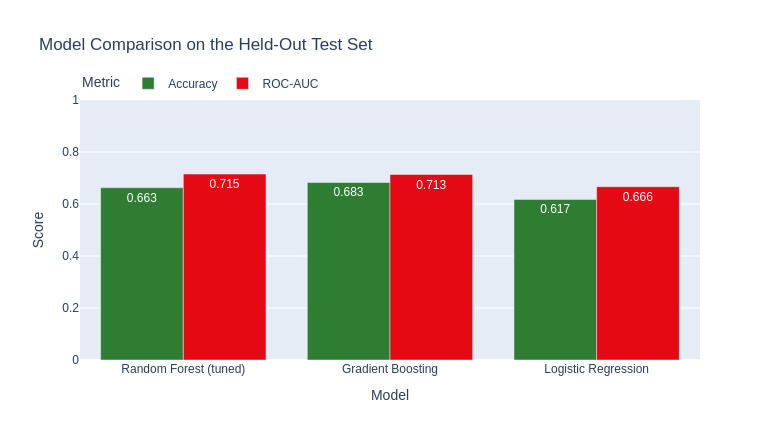

In [7]:
comp = results_df.reset_index().melt(id_vars="Model", value_vars=["Accuracy", "ROC-AUC"],
                                     var_name="Metric", value_name="Score")
fig = px.bar(comp, x="Model", y="Score", color="Metric", barmode="group",
             title="Model Comparison on the Held-Out Test Set", text=comp["Score"].round(3),
             color_discrete_sequence=["#2E7D32", "#E50914"])
fig.update_yaxes(range=[0, 1])
fig.update_layout(width=780, height=440, legend=dict(orientation="h", y=1.12))
fig.show()


## 7. ROC curves

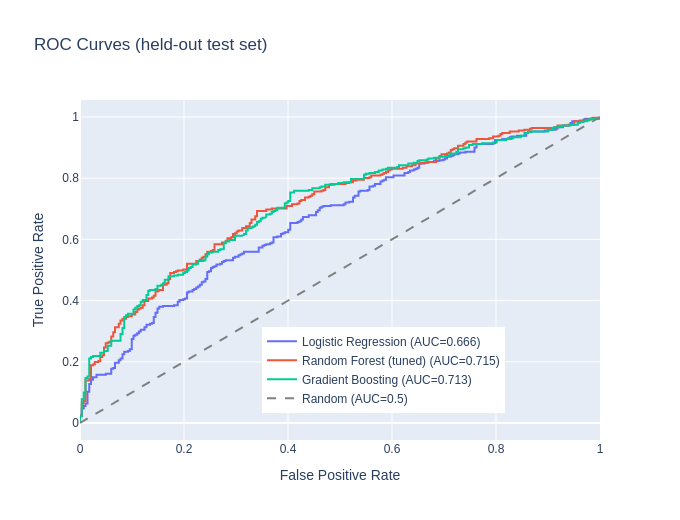

In [8]:
fig = go.Figure()
for name, (fpr, tpr, auc) in roc_data.items():
    fig.add_trace(go.Scatter(x=fpr, y=tpr, mode="lines", name=f"{name} (AUC={auc:.3f})"))
fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode="lines", line=dict(dash="dash", color="gray"),
                         name="Random (AUC=0.5)"))
fig.update_layout(title="ROC Curves (held-out test set)", xaxis_title="False Positive Rate",
                  yaxis_title="True Positive Rate", width=680, height=520, legend=dict(x=0.35, y=0.08))
fig.show()


## 8. Confusion matrix — best model

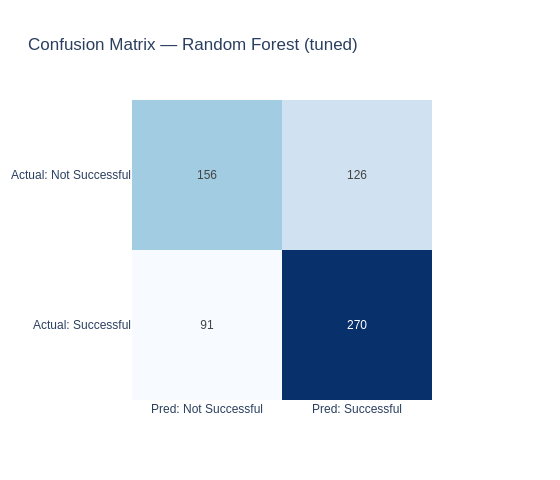

In [9]:
best = fitted[best_name]
cm = confusion_matrix(y_test, best.predict(X_test))
labels = ["Not Successful", "Successful"]
fig = px.imshow(cm, text_auto=True, color_continuous_scale="Blues",
                x=[f"Pred: {l}" for l in labels], y=[f"Actual: {l}" for l in labels],
                title=f"Confusion Matrix — {best_name}")
fig.update_layout(width=560, height=480, coloraxis_showscale=False)
fig.show()


## 9. Feature importance
Which pre-release features drive the predictions?

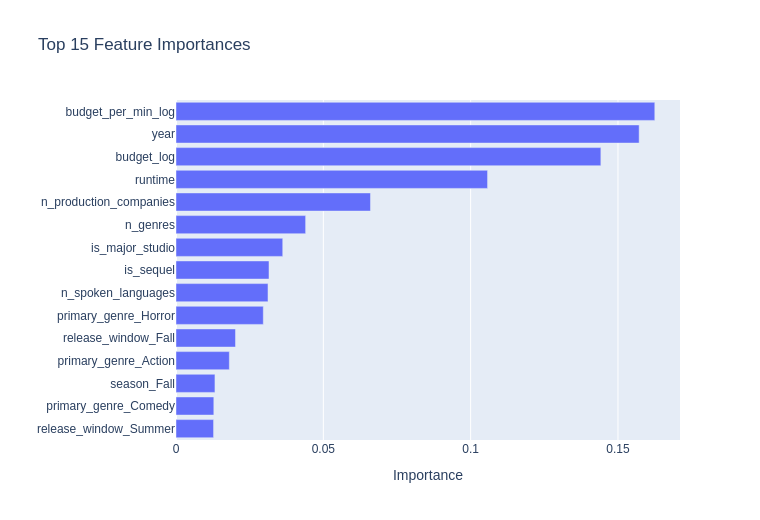

,feature,importance
6,budget_per_min_log,0.163
5,year,0.157
0,budget_log,0.144
1,runtime,0.106
3,n_production_companies,0.066
2,n_genres,0.044
12,is_major_studio,0.036
11,is_sequel,0.032
4,n_spoken_languages,0.031
24,primary_genre_Horror,0.030


In [10]:
imp_pipe = fitted[best_name] if hasattr(fitted[best_name].named_steps["model"], "feature_importances_") \
           else fitted["Gradient Boosting"]
feat_names = imp_pipe.named_steps["prep"].get_feature_names_out()
importances = imp_pipe.named_steps["model"].feature_importances_

imp_df = (pd.DataFrame({"feature": feat_names, "importance": importances})
          .sort_values("importance", ascending=False).head(15))
imp_df["feature"] = imp_df["feature"].str.replace("num__|flag__|cat__", "", regex=True)

fig = px.bar(imp_df.sort_values("importance"), x="importance", y="feature", orientation="h",
             title="Top 15 Feature Importances",
             labels={"importance": "Importance", "feature": ""})
fig.update_layout(width=760, height=520)
fig.show()
imp_df.round(4)


## 10. Results summary & takeaways

- **All models beat the ~56% majority baseline** on both the held-out test set and 5-fold cross-validation —
  pre-release attributes carry real predictive signal.
- **The engineered features paid off.** Adding the franchise/sequel flag, major-studio flag, release year, and
  spend-intensity lifted ROC-AUC meaningfully versus the EDA-only feature set (~0.66 → ~0.68 cross-validated,
  ~0.71 on the held-out test split).
- **Budget remains the strongest single predictor**, with the sequel and studio signals, runtime, era, and the
  release-timing features contributing on top.
- Performance is honest rather than inflated: much of what decides a film's fate (reviews, word of mouth,
  marketing execution, competition) only exists *after* release and is deliberately excluded to avoid leakage.
- The most robust model (best cross-validated ROC-AUC) is served in the **Streamlit app** (`app/app.py`), where a
  user enters a hypothetical film's pre-release attributes and receives a predicted probability of success.
